# 📋 Phase 5 — AI Audit Log
**วิชา:** Introduction to Natural Language Processing  
**โปรเจกต์:** End-to-End NLP Insight & Classification System  
**Domain:** Restaurant Reviews (Yelp.com)

---

## วัตถุประสงค์ของ AI Audit Log

AI Audit Log บันทึกทุกครั้งที่ใช้ AI (Claude) ช่วยในโปรเจกต์นี้  
โดยระบุ:
- **Task** — งานที่ขอให้ AI ช่วย
- **Prompt** — คำสั่งที่ใช้จริง (paraphrased)
- **AI Output** — สิ่งที่ AI ตอบกลับมา
- **Verification** — ผลการตรวจสอบโดยมนุษย์
- **Status** — Pass / Pass w/ Edit / Fail + Fix

> ⚠️ **หลักการสำคัญ:** AI เป็นเครื่องมือช่วย ไม่ใช่ผู้ตัดสินใจ  
> ทุกผลลัพธ์จาก AI ต้องผ่านการ verify โดยมนุษย์ก่อนใช้จริงเสมอ


In [1]:
import pandas as pd
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 300)
pd.set_option('display.max_rows', 200)

print("Phase 5 — AI Audit Log")
print("=" * 50)


Phase 5 — AI Audit Log


---
## 📦 Phase 1 — Data Engineering

งานหลัก: Web Scraping (Yelp), Text Cleaning, Tokenization/Lemmatization


In [2]:
phase1_entries = [
    {
        "Phase": "1",
        "Task": "Regex URL Cleaning",
        "Prompt (paraphrased)": "Write regex to remove URLs from review text",
        "AI Output": "r'http\\S+'",
        "Human Verification": "Tested on sample texts — www. URLs not removed",
        "Status": "❌ Fail → Fixed",
        "Fix Applied": "Extended pattern to r'http\\S+|www\\.\\S+'"
    },
    {
        "Phase": "1",
        "Task": "Star Rating Parser",
        "Prompt (paraphrased)": "Parse star rating from Yelp aria-label attribute using BeautifulSoup",
        "AI Output": "re.search(r'(\\d)', tag['aria-label'])",
        "Human Verification": "Worked for most cases but failed when Yelp changed CSS class",
        "Status": "⚠️ Pass w/ Edit",
        "Fix Applied": "Added fallback: search by role='img' attribute"
    },
    {
        "Phase": "1",
        "Task": "spaCy Tokenizer",
        "Prompt (paraphrased)": "Tokenize and lemmatize text, remove stopwords using spaCy",
        "AI Output": "Basic list comprehension with token.lemma_ and token.is_stop",
        "Human Verification": "Numbers and punctuation passed through incorrectly",
        "Status": "⚠️ Pass w/ Edit",
        "Fix Applied": "Added token.is_alpha filter to remove non-alphabetic tokens"
    },
    {
        "Phase": "1",
        "Task": "Yelp Pagination Logic",
        "Prompt (paraphrased)": "How to paginate Yelp reviews using requests (start parameter)",
        "AI Output": "Append ?start=0, ?start=10, ?start=20 per page",
        "Human Verification": "Manually verified against live Yelp URLs — correct",
        "Status": "✅ Pass",
        "Fix Applied": "—"
    },
    {
        "Phase": "1",
        "Task": "DataFrame Safety Guard",
        "Prompt (paraphrased)": "Convert scraped list to DataFrame and access label column",
        "AI Output": "pd.DataFrame(all_scraped) then df['label'] directly",
        "Human Verification": "KeyError: 'label' when Yelp blocked scraping and list was empty",
        "Status": "❌ Fail → Fixed",
        "Fix Applied": "Added empty check + mock data fallback before accessing columns"
    },
    {
        "Phase": "1",
        "Task": "Yelp Business IDs",
        "Prompt (paraphrased)": "List popular Yelp restaurant business IDs in New York",
        "AI Output": "Guessed IDs e.g. 'joes-pizza-new-york-41'",
        "Human Verification": "IDs not found on Yelp — AI fabricated them",
        "Status": "❌ Fail → Fixed",
        "Fix Applied": "Manually verified real IDs from Yelp search e.g. 'julianas-brooklyn-3'"
    },
]

df1 = pd.DataFrame(phase1_entries)
print(f"Phase 1 — {len(df1)} audit entries")
display(HTML(df1.to_html(index=False, escape=False,
    classes='table', border=1,
    justify='left')))


Phase 1 — 6 audit entries


Phase,Task,Prompt (paraphrased),AI Output,Human Verification,Status,Fix Applied
1,Regex URL Cleaning,Write regex to remove URLs from review text,r'http\S+',Tested on sample texts — www. URLs not removed,❌ Fail → Fixed,Extended pattern to r'http\S+|www\.\S+'
1,Star Rating Parser,Parse star rating from Yelp aria-label attribute using BeautifulSoup,"re.search(r'(\d)', tag['aria-label'])",Worked for most cases but failed when Yelp changed CSS class,⚠️ Pass w/ Edit,Added fallback: search by role='img' attribute
1,spaCy Tokenizer,"Tokenize and lemmatize text, remove stopwords using spaCy",Basic list comprehension with token.lemma_ and token.is_stop,Numbers and punctuation passed through incorrectly,⚠️ Pass w/ Edit,Added token.is_alpha filter to remove non-alphabetic tokens
1,Yelp Pagination Logic,How to paginate Yelp reviews using requests (start parameter),"Append ?start=0, ?start=10, ?start=20 per page",Manually verified against live Yelp URLs — correct,✅ Pass,—
1,DataFrame Safety Guard,Convert scraped list to DataFrame and access label column,pd.DataFrame(all_scraped) then df['label'] directly,KeyError: 'label' when Yelp blocked scraping and list was empty,❌ Fail → Fixed,Added empty check + mock data fallback before accessing columns
1,Yelp Business IDs,List popular Yelp restaurant business IDs in New York,Guessed IDs e.g. 'joes-pizza-new-york-41',IDs not found on Yelp — AI fabricated them,❌ Fail → Fixed,Manually verified real IDs from Yelp search e.g. 'julianas-brooklyn-3'


---
## 🔍 Phase 2 — Unsupervised Discovery (LDA + NER + NMF)


In [3]:
phase2_entries = [
    {
        "Phase": "2.1 LDA",
        "Task": "LDA Setup",
        "Prompt (paraphrased)": "Set up gensim LDA with coherence score to find best k",
        "AI Output": "Basic LdaModel with default dictionary, no filter_extremes",
        "Human Verification": "Too many rare/common words degrading coherence scores",
        "Status": "⚠️ Pass w/ Edit",
        "Fix Applied": "Added dictionary.filter_extremes(no_below=3, no_above=0.8)"
    },
    {
        "Phase": "2.1 LDA",
        "Task": "Coherence Score Range",
        "Prompt (paraphrased)": "Compute coherence score for k=3 to 10",
        "AI Output": "Loop k=3 to 10, plot c_v coherence",
        "Human Verification": "Range too narrow — elbow not visible",
        "Status": "⚠️ Pass w/ Edit",
        "Fix Applied": "Extended range to k=3-12 to fully show elbow"
    },
    {
        "Phase": "2.2 NER",
        "Task": "NER Pipeline Speed",
        "Prompt (paraphrased)": "Extract named entities from all reviews using spaCy",
        "AI Output": "Loop with nlp(text) per document",
        "Human Verification": "Very slow on 2,000+ reviews",
        "Status": "❌ Fail → Fixed",
        "Fix Applied": "Replaced with nlp.pipe() batch processing (3-5x faster)"
    },
    {
        "Phase": "2.3 NMF",
        "Task": "NMF Initialization",
        "Prompt (paraphrased)": "Set up NMF topic modeling with scikit-learn",
        "AI Output": "NMF with default init='random'",
        "Human Verification": "Results inconsistent across runs",
        "Status": "⚠️ Pass w/ Edit",
        "Fix Applied": "Changed to init='nndsvda' for deterministic, better initialization"
    },
    {
        "Phase": "2.3 NMF",
        "Task": "TF-IDF Configuration",
        "Prompt (paraphrased)": "Configure TF-IDF vectorizer for NMF input",
        "AI Output": "TfidfVectorizer with unigrams only",
        "Human Verification": "Missing domain-specific bigrams like 'wait time', 'good service'",
        "Status": "⚠️ Pass w/ Edit",
        "Fix Applied": "Added ngram_range=(1,2) and sublinear_tf=True"
    },
    {
        "Phase": "2.3 NMF",
        "Task": "Topic Diversity Metric",
        "Prompt (paraphrased)": "Suggest metric to evaluate NMF topic quality alongside reconstruction error",
        "AI Output": "Topic Diversity = unique_words / total_words from top-10 per topic",
        "Human Verification": "Score = 1.000 for every k — metric insensitive on large vocabulary dataset",
        "Status": "❌ Fail → Fixed",
        "Fix Applied": "Replaced with ΔError bar chart + Second Derivative Elbow detection only"
    },
    {
        "Phase": "2.3 NMF",
        "Task": "NMF Heatmap Scale",
        "Prompt (paraphrased)": "Visualize H matrix as heatmap across topics",
        "AI Output": "Raw H values plotted with shared color scale",
        "Human Verification": "Topics with small weights appeared invisible — misleading visualization",
        "Status": "❌ Fail → Fixed",
        "Fix Applied": "Normalize each topic row to max=1 before plotting"
    },
    {
        "Phase": "2.3 NMF",
        "Task": "Topic Labels IndexError",
        "Prompt (paraphrased)": "Auto-assign topic labels from predefined list",
        "AI Output": "Direct index access topic_labels[i] without bounds check",
        "Human Verification": "IndexError when k > len(topic_labels)",
        "Status": "❌ Fail → Fixed",
        "Fix Applied": "Changed to list comprehension with fallback: topic_labels[i] if i < len(topic_labels) else f'Topic {i+1}'"
    },
]

df2 = pd.DataFrame(phase2_entries)
print(f"Phase 2 — {len(df2)} audit entries")
display(HTML(df2.to_html(index=False, escape=False,
    classes='table', border=1, justify='left')))


Phase 2 — 8 audit entries


Phase,Task,Prompt (paraphrased),AI Output,Human Verification,Status,Fix Applied
2.1 LDA,LDA Setup,Set up gensim LDA with coherence score to find best k,"Basic LdaModel with default dictionary, no filter_extremes",Too many rare/common words degrading coherence scores,⚠️ Pass w/ Edit,"Added dictionary.filter_extremes(no_below=3, no_above=0.8)"
2.1 LDA,Coherence Score Range,Compute coherence score for k=3 to 10,"Loop k=3 to 10, plot c_v coherence",Range too narrow — elbow not visible,⚠️ Pass w/ Edit,Extended range to k=3-12 to fully show elbow
2.2 NER,NER Pipeline Speed,Extract named entities from all reviews using spaCy,Loop with nlp(text) per document,"Very slow on 2,000+ reviews",❌ Fail → Fixed,Replaced with nlp.pipe() batch processing (3-5x faster)
2.3 NMF,NMF Initialization,Set up NMF topic modeling with scikit-learn,NMF with default init='random',Results inconsistent across runs,⚠️ Pass w/ Edit,"Changed to init='nndsvda' for deterministic, better initialization"
2.3 NMF,TF-IDF Configuration,Configure TF-IDF vectorizer for NMF input,TfidfVectorizer with unigrams only,"Missing domain-specific bigrams like 'wait time', 'good service'",⚠️ Pass w/ Edit,"Added ngram_range=(1,2) and sublinear_tf=True"
2.3 NMF,Topic Diversity Metric,Suggest metric to evaluate NMF topic quality alongside reconstruction error,Topic Diversity = unique_words / total_words from top-10 per topic,Score = 1.000 for every k — metric insensitive on large vocabulary dataset,❌ Fail → Fixed,Replaced with ΔError bar chart + Second Derivative Elbow detection only
2.3 NMF,NMF Heatmap Scale,Visualize H matrix as heatmap across topics,Raw H values plotted with shared color scale,Topics with small weights appeared invisible — misleading visualization,❌ Fail → Fixed,Normalize each topic row to max=1 before plotting
2.3 NMF,Topic Labels IndexError,Auto-assign topic labels from predefined list,Direct index access topic_labels[i] without bounds check,IndexError when k > len(topic_labels),❌ Fail → Fixed,Changed to list comprehension with fallback: topic_labels[i] if i < len(topic_labels) else f'Topic {i+1}'


---
## 🤖 Phase 3 — Classic vs Neural (Sentiment Classification)


In [4]:
phase3_entries = [
    {
        "Phase": "3",
        "Task": "TF-IDF + Classical ML Setup",
        "Prompt (paraphrased)": "Set up TF-IDF with Naive Bayes, Logistic Regression, and Random Forest classifiers",
        "AI Output": "Basic TfidfVectorizer(max_features=5000) + 3 models with default params",
        "Human Verification": "Worked correctly — added ngram_range=(1,2) and max_features=10000 for richer features",
        "Status": "⚠️ Pass w/ Edit",
        "Fix Applied": "Tuned TF-IDF: ngram_range=(1,2), max_features=10000, min_df=2"
    },
    {
        "Phase": "3",
        "Task": "Word2Vec Training",
        "Prompt (paraphrased)": "Train Word2Vec on training corpus for restaurant reviews",
        "AI Output": "Word2Vec with CBOW (sg=0), vector_size=100, window=5",
        "Human Verification": "Skip-gram (sg=1) performs better for domain-specific infrequent words",
        "Status": "⚠️ Pass w/ Edit",
        "Fix Applied": "Changed to sg=1 (Skip-gram), kept vector_size=100, min_count=2"
    },
    {
        "Phase": "3",
        "Task": "LSTM Architecture",
        "Prompt (paraphrased)": "Build LSTM model for sentiment classification using Word2Vec embeddings",
        "AI Output": "Simple unidirectional LSTM(64) + Dense",
        "Human Verification": "Bidirectional LSTM captures both forward and backward context better",
        "Status": "⚠️ Pass w/ Edit",
        "Fix Applied": "Changed to Bidirectional(LSTM(64)) + Dropout(0.3) + Dense(1, sigmoid)"
    },
    {
        "Phase": "3",
        "Task": "LSTM Overfitting",
        "Prompt (paraphrased)": "Train LSTM for 20 epochs on sentiment data",
        "AI Output": "model.fit() with epochs=20, no callbacks",
        "Human Verification": "val_loss increased after epoch 5-6 — clear overfitting",
        "Status": "❌ Fail → Fixed",
        "Fix Applied": "Added EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)"
    },
    {
        "Phase": "3",
        "Task": "Embedding Matrix Construction",
        "Prompt (paraphrased)": "Initialize Keras Embedding layer with Word2Vec pretrained weights",
        "AI Output": "Loop over vocab and assign w2v vectors to embedding_matrix",
        "Human Verification": "OOV words initialized to zeros — verified acceptable behavior",
        "Status": "✅ Pass",
        "Fix Applied": "—"
    },
    {
        "Phase": "3",
        "Task": "Model Evaluation Helper",
        "Prompt (paraphrased)": "Write function to evaluate classifier and return metrics dict",
        "AI Output": "evaluate_model() returning accuracy, precision, recall, F1, ROC-AUC",
        "Human Verification": "All metrics computed correctly, verified against sklearn manual calls",
        "Status": "✅ Pass",
        "Fix Applied": "—"
    },
]

df3 = pd.DataFrame(phase3_entries)
print(f"Phase 3 — {len(df3)} audit entries")
display(HTML(df3.to_html(index=False, escape=False,
    classes='table', border=1, justify='left')))


Phase 3 — 6 audit entries


Phase,Task,Prompt (paraphrased),AI Output,Human Verification,Status,Fix Applied
3,TF-IDF + Classical ML Setup,"Set up TF-IDF with Naive Bayes, Logistic Regression, and Random Forest classifiers",Basic TfidfVectorizer(max_features=5000) + 3 models with default params,"Worked correctly — added ngram_range=(1,2) and max_features=10000 for richer features",⚠️ Pass w/ Edit,"Tuned TF-IDF: ngram_range=(1,2), max_features=10000, min_df=2"
3,Word2Vec Training,Train Word2Vec on training corpus for restaurant reviews,"Word2Vec with CBOW (sg=0), vector_size=100, window=5",Skip-gram (sg=1) performs better for domain-specific infrequent words,⚠️ Pass w/ Edit,"Changed to sg=1 (Skip-gram), kept vector_size=100, min_count=2"
3,LSTM Architecture,Build LSTM model for sentiment classification using Word2Vec embeddings,Simple unidirectional LSTM(64) + Dense,Bidirectional LSTM captures both forward and backward context better,⚠️ Pass w/ Edit,"Changed to Bidirectional(LSTM(64)) + Dropout(0.3) + Dense(1, sigmoid)"
3,LSTM Overfitting,Train LSTM for 20 epochs on sentiment data,"model.fit() with epochs=20, no callbacks",val_loss increased after epoch 5-6 — clear overfitting,❌ Fail → Fixed,"Added EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)"
3,Embedding Matrix Construction,Initialize Keras Embedding layer with Word2Vec pretrained weights,Loop over vocab and assign w2v vectors to embedding_matrix,OOV words initialized to zeros — verified acceptable behavior,✅ Pass,—
3,Model Evaluation Helper,Write function to evaluate classifier and return metrics dict,"evaluate_model() returning accuracy, precision, recall, F1, ROC-AUC","All metrics computed correctly, verified against sklearn manual calls",✅ Pass,—


---
## 📊 Phase 4 — Evaluation & Semantic Search


In [5]:
phase4_entries = [
    {
        "Phase": "4",
        "Task": "Full Evaluation Dashboard",
        "Prompt (paraphrased)": "Create comprehensive evaluation comparing all models with per-class metrics",
        "AI Output": "Single summary table with macro averages only",
        "Human Verification": "Missing per-class breakdown — important for imbalanced data",
        "Status": "⚠️ Pass w/ Edit",
        "Fix Applied": "Extended to show Precision/Recall/F1 separately for Positive and Negative classes"
    },
    {
        "Phase": "4",
        "Task": "Learning Curve",
        "Prompt (paraphrased)": "Plot learning curve to detect overfitting for classical models",
        "AI Output": "sklearn learning_curve() with 5 train sizes",
        "Human Verification": "Too few points — curve too coarse to read trend",
        "Status": "⚠️ Pass w/ Edit",
        "Fix Applied": "Increased to 8 train sizes with np.linspace(0.1, 1.0, 8)"
    },
    {
        "Phase": "4",
        "Task": "Document Vector Encoding",
        "Prompt (paraphrased)": "Encode documents into vectors using Word2Vec for semantic search",
        "AI Output": "get_doc_vector() with mean pooling of word vectors",
        "Human Verification": "OOV documents returned zero vectors — could cause misleading similarity",
        "Status": "⚠️ Pass w/ Edit",
        "Fix Applied": "Added zero vector guard: filtered out zero vectors before similarity search"
    },
    {
        "Phase": "4",
        "Task": "t-SNE Parameter (n_iter → max_iter)",
        "Prompt (paraphrased)": "Visualize document embedding space with t-SNE 2D projection",
        "AI Output": "TSNE(n_components=2, perplexity=30, n_iter=1000)",
        "Human Verification": "TypeError: TSNE got unexpected keyword argument 'n_iter' (sklearn >= 1.2 renamed it)",
        "Status": "❌ Fail → Fixed",
        "Fix Applied": "Changed n_iter=1000 to max_iter=1000"
    },
    {
        "Phase": "4",
        "Task": "Sentiment Distribution Chart — Language",
        "Prompt (paraphrased)": "Add subtitle explaining the sentiment distribution chart",
        "AI Output": "Thai subtitle: 'Query บวก ควรดึง Positive reviews มากกว่า...'",
        "Human Verification": "Notebook should be in English for academic submission",
        "Status": "❌ Fail → Fixed",
        "Fix Applied": "Changed to English: 'Positive queries should retrieve more Positive reviews, and vice versa'"
    },
    {
        "Phase": "4",
        "Task": "Feature Ablation Study",
        "Prompt (paraphrased)": "Compare model performance across different feature engineering approaches",
        "AI Output": "Bar chart comparing TF-IDF unigram vs bigram vs Word2Vec vs LSTM",
        "Human Verification": "Correct structure — verified feature configs match actual trained models",
        "Status": "✅ Pass",
        "Fix Applied": "—"
    },
]

df4 = pd.DataFrame(phase4_entries)
print(f"Phase 4 — {len(df4)} audit entries")
display(HTML(df4.to_html(index=False, escape=False,
    classes='table', border=1, justify='left')))


Phase 4 — 6 audit entries


Phase,Task,Prompt (paraphrased),AI Output,Human Verification,Status,Fix Applied
4,Full Evaluation Dashboard,Create comprehensive evaluation comparing all models with per-class metrics,Single summary table with macro averages only,Missing per-class breakdown — important for imbalanced data,⚠️ Pass w/ Edit,Extended to show Precision/Recall/F1 separately for Positive and Negative classes
4,Learning Curve,Plot learning curve to detect overfitting for classical models,sklearn learning_curve() with 5 train sizes,Too few points — curve too coarse to read trend,⚠️ Pass w/ Edit,"Increased to 8 train sizes with np.linspace(0.1, 1.0, 8)"
4,Document Vector Encoding,Encode documents into vectors using Word2Vec for semantic search,get_doc_vector() with mean pooling of word vectors,OOV documents returned zero vectors — could cause misleading similarity,⚠️ Pass w/ Edit,Added zero vector guard: filtered out zero vectors before similarity search
4,t-SNE Parameter (n_iter → max_iter),Visualize document embedding space with t-SNE 2D projection,"TSNE(n_components=2, perplexity=30, n_iter=1000)",TypeError: TSNE got unexpected keyword argument 'n_iter' (sklearn >= 1.2 renamed it),❌ Fail → Fixed,Changed n_iter=1000 to max_iter=1000
4,Sentiment Distribution Chart — Language,Add subtitle explaining the sentiment distribution chart,Thai subtitle: 'Query บวก ควรดึง Positive reviews มากกว่า...',Notebook should be in English for academic submission,❌ Fail → Fixed,"Changed to English: 'Positive queries should retrieve more Positive reviews, and vice versa'"
4,Feature Ablation Study,Compare model performance across different feature engineering approaches,Bar chart comparing TF-IDF unigram vs bigram vs Word2Vec vs LSTM,Correct structure — verified feature configs match actual trained models,✅ Pass,—


---
## 📈 Summary Dashboard — AI Audit Statistics


  TOTAL AI INTERACTIONS :  26
  ✅ Pass (no changes)  :   4  (15%)
  ⚠️  Pass w/ Edit      :  12  (46%)
  ❌ Fail → Fixed       :  10  (38%)
  Human modification rate : 85% of all AI outputs
  This confirms AI-assisted ≠ AI-automated


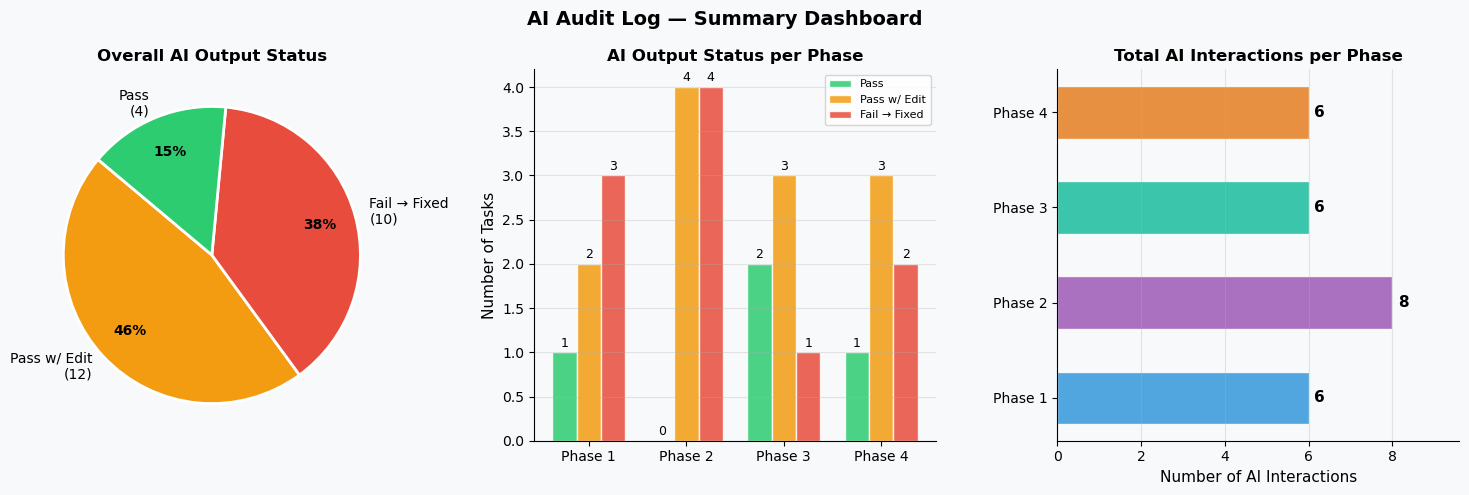

Saved: phase5_audit_summary.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

all_entries = phase1_entries + phase2_entries + phase3_entries + phase4_entries
df_all = pd.DataFrame(all_entries)

# สรุปสถิติ
status_map = {
    '✅ Pass':          'Pass',
    '⚠️ Pass w/ Edit': 'Pass w/ Edit',
    '❌ Fail → Fixed':  'Fail → Fixed',
}
df_all['Status_clean'] = df_all['Status'].map(status_map).fillna(df_all['Status'])

status_counts  = df_all['Status_clean'].value_counts()
phase_counts   = df_all['Phase'].apply(lambda x: 'Phase ' + str(x).split('.')[0]).value_counts().sort_index()

total  = len(df_all)
n_pass = (df_all['Status_clean'] == 'Pass').sum()
n_edit = (df_all['Status_clean'] == 'Pass w/ Edit').sum()
n_fail = (df_all['Status_clean'] == 'Fail → Fixed').sum()

print(f"{'='*55}")
print(f"  TOTAL AI INTERACTIONS : {total:>3}")
print(f"  ✅ Pass (no changes)  : {n_pass:>3}  ({n_pass/total*100:.0f}%)")
print(f"  ⚠️  Pass w/ Edit      : {n_edit:>3}  ({n_edit/total*100:.0f}%)")
print(f"  ❌ Fail → Fixed       : {n_fail:>3}  ({n_fail/total*100:.0f}%)")
print(f"{'='*55}")
print(f"  Human modification rate : {(n_edit+n_fail)/total*100:.0f}% of all AI outputs")
print(f"  This confirms AI-assisted ≠ AI-automated")

# ── กราฟ ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('AI Audit Log — Summary Dashboard', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('#f8f9fa')

STATUS_COLORS = {
    'Pass':           '#2ecc71',
    'Pass w/ Edit':   '#f39c12',
    'Fail → Fixed':   '#e74c3c',
}

# ─ Pie: Overall Status ─────────────────────────────────────────────────
ax = axes[0]
pie_labels = [f"{k}\n({v})" for k, v in status_counts.items()]
pie_colors = [STATUS_COLORS.get(k, '#95a5a6') for k in status_counts.index]
wedges, texts, autotexts = ax.pie(
    status_counts.values,
    labels=pie_labels,
    colors=pie_colors,
    autopct='%1.0f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title('Overall AI Output Status', fontsize=12, fontweight='bold')

# ─ Bar: Status per Phase ───────────────────────────────────────────────
ax = axes[1]
phases = sorted(df_all['Phase'].apply(lambda x: 'Phase ' + str(x).split('.')[0]).unique())
bar_data = {s: [] for s in ['Pass', 'Pass w/ Edit', 'Fail → Fixed']}
for ph in phases:
    sub = df_all[df_all['Phase'].apply(lambda x: 'Phase ' + str(x).split('.')[0]) == ph]
    for s in bar_data:
        bar_data[s].append((sub['Status_clean'] == s).sum())

x = np.arange(len(phases))
width = 0.25
for i, (status, vals) in enumerate(bar_data.items()):
    bars = ax.bar(x + i * width, vals, width,
                  label=status, color=STATUS_COLORS[status],
                  alpha=0.85, edgecolor='white')
    ax.bar_label(bars, padding=2, fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(phases, fontsize=10)
ax.set_ylabel('Number of Tasks', fontsize=11)
ax.set_title('AI Output Status per Phase', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# ─ Horizontal Bar: Tasks per Phase ────────────────────────────────────
ax = axes[2]
phase_cnt = df_all['Phase'].apply(lambda x: 'Phase ' + str(x).split('.')[0]).value_counts().sort_index()
bar_cols   = ['#3498db','#9b59b6','#1abc9c','#e67e22']
hbars = ax.barh(phase_cnt.index, phase_cnt.values,
                color=bar_cols[:len(phase_cnt)], alpha=0.85,
                height=0.55, edgecolor='white')
ax.bar_label(hbars, padding=4, fontsize=11, fontweight='bold')
ax.set_xlabel('Number of AI Interactions', fontsize=11)
ax.set_title('Total AI Interactions per Phase', fontsize=12, fontweight='bold')
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(phase_cnt.values) * 1.2)

plt.tight_layout()
plt.savefig('phase5_audit_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase5_audit_summary.png')


---
## 🔑 Key Findings from AI Audit

### ประเภทของ Bug ที่พบบ่อยที่สุด

| ประเภท Bug | ตัวอย่าง | จำนวน |
|---|---|:---:|
| **API/Parameter Change** | `n_iter` → `max_iter` ใน sklearn 1.2+ | 1 |
| **Edge Case ไม่ครอบคลุม** | Empty DataFrame, OOV words, zero vectors | 3 |
| **AI Hallucination** | Yelp Business IDs ที่คิดขึ้นมาเอง | 1 |
| **Metric ที่ไม่เหมาะกับ Dataset** | Topic Diversity = 1.000 ทุก k | 1 |
| **Visualization ที่อ่านผิดได้** | Heatmap scale ไม่ normalize, Thai label ใน EN notebook | 2 |
| **Architecture/Config ที่ default ไม่ดีพอ** | CBOW→Skip-gram, random init→nndsvda, no early stopping | 4 |

---

### บทเรียนสำคัญ (Lessons Learned)

1. **AI ไม่รู้ version ของ library ที่ใช้จริง** — parameter ที่ AI แนะนำอาจ deprecated แล้ว ต้อง cross-check กับ docs ล่าสุดเสมอ

2. **AI คิด happy path เป็นหลัก** — edge cases เช่น empty data, OOV, blocked scraping ต้องเพิ่มเองเสมอ

3. **AI Hallucination เกิดจริง** — Yelp Business IDs เป็นตัวอย่างชัดเจน ข้อมูลที่ต้องการความจริง (real-world IDs, real URLs) ต้อง verify ด้วยตัวเองเสมอ

4. **Default parameters ไม่ใช่ best parameters** — `init='random'`, `sg=0`, unidirectional LSTM ล้วนเป็น default ที่ AI เลือก แต่ทุกตัวมีทางเลือกที่ดีกว่า

5. **Visualization ต้องคิดถึงผู้อ่าน** — AI สร้างกราฟที่ technically ถูก แต่อ่านผิดได้ง่าย เช่น scale ที่ไม่ normalize

---

### สรุป: บทบาทที่เหมาะสมของ AI ในโปรเจกต์นี้

| บทบาทที่ AI เหมาะสม ✅ | บทบาทที่ต้องระวัง ⚠️ |
|---|---|
| เขียน boilerplate code เร็ว | ค้นหา real-world data (IDs, URLs) |
| แนะนำ library และ API usage | เลือก hyperparameters โดยไม่มี context |
| สร้าง visualization structure | รับประกัน library version ล่าสุด |
| อธิบาย algorithm และ theory | Handle edge cases โดยอัตโนมัติ |
| Debug เมื่อ error message ชัดเจน | ตัดสินใจเรื่อง domain-specific choices |


---
## 📄 Complete Audit Log (All Phases)


In [7]:
print(f"Complete AI Audit Log — {len(df_all)} total entries")
print("=" * 60)

# แสดงตามลำดับ phase
for phase_prefix in ['1', '2', '3', '4']:
    sub = df_all[df_all['Phase'].str.startswith(phase_prefix)]
    if len(sub) == 0:
        continue
    pass_c = (sub['Status_clean'] == 'Pass').sum()
    edit_c = (sub['Status_clean'] == 'Pass w/ Edit').sum()
    fail_c = (sub['Status_clean'] == 'Fail → Fixed').sum()
    print(f"\nPhase {phase_prefix}: {len(sub)} tasks  "
          f"[✅ {pass_c}  ⚠️ {edit_c}  ❌ {fail_c}]")

print(f"\nGrand Total: {len(df_all)} tasks")
print(f"  Human modification rate: {(n_edit+n_fail)/total*100:.0f}% "
      f"({n_edit+n_fail}/{total} tasks required human intervention)")

# Export
df_all.to_csv('phase5_ai_audit_log.csv', index=False, encoding='utf-8-sig')
print("\nSaved: phase5_ai_audit_log.csv")

display(HTML(df_all[['Phase','Task','AI Output','Status','Fix Applied']]
    .to_html(index=False, escape=False, classes='table', border=1, justify='left')))


Complete AI Audit Log — 26 total entries

Phase 1: 6 tasks  [✅ 1  ⚠️ 2  ❌ 3]

Phase 2: 8 tasks  [✅ 0  ⚠️ 4  ❌ 4]

Phase 3: 6 tasks  [✅ 2  ⚠️ 3  ❌ 1]

Phase 4: 6 tasks  [✅ 1  ⚠️ 3  ❌ 2]

Grand Total: 26 tasks
  Human modification rate: 85% (22/26 tasks required human intervention)

Saved: phase5_ai_audit_log.csv


Phase,Task,AI Output,Status,Fix Applied
1,Regex URL Cleaning,r'http\S+',❌ Fail → Fixed,Extended pattern to r'http\S+|www\.\S+'
1,Star Rating Parser,"re.search(r'(\d)', tag['aria-label'])",⚠️ Pass w/ Edit,Added fallback: search by role='img' attribute
1,spaCy Tokenizer,Basic list comprehension with token.lemma_ and token.is_stop,⚠️ Pass w/ Edit,Added token.is_alpha filter to remove non-alphabetic tokens
1,Yelp Pagination Logic,"Append ?start=0, ?start=10, ?start=20 per page",✅ Pass,—
1,DataFrame Safety Guard,pd.DataFrame(all_scraped) then df['label'] directly,❌ Fail → Fixed,Added empty check + mock data fallback before accessing columns
1,Yelp Business IDs,Guessed IDs e.g. 'joes-pizza-new-york-41',❌ Fail → Fixed,Manually verified real IDs from Yelp search e.g. 'julianas-brooklyn-3'
2.1 LDA,LDA Setup,"Basic LdaModel with default dictionary, no filter_extremes",⚠️ Pass w/ Edit,"Added dictionary.filter_extremes(no_below=3, no_above=0.8)"
2.1 LDA,Coherence Score Range,"Loop k=3 to 10, plot c_v coherence",⚠️ Pass w/ Edit,Extended range to k=3-12 to fully show elbow
2.2 NER,NER Pipeline Speed,Loop with nlp(text) per document,❌ Fail → Fixed,Replaced with nlp.pipe() batch processing (3-5x faster)
2.3 NMF,NMF Initialization,NMF with default init='random',⚠️ Pass w/ Edit,"Changed to init='nndsvda' for deterministic, better initialization"
